In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Load data
df = pd.read_csv("../data/featured_sample.csv")
df['date'] = pd.to_datetime(df['date'])
inventory = pd.read_csv("../data/inventory_optimization.csv")

print("Data loaded successfully!")
print("Featured data:", df.shape)
print("Inventory data:", inventory.shape)

Data loaded successfully!
Featured data: (500000, 32)
Inventory data: (30490, 11)


In [2]:
# Item Value Analysis - similar to LTV concept
# Calculate total value per item over time

item_value = df.groupby(['item_id', 'store_id', 'cat_id']).agg(
    total_sales=('sales', 'sum'),
    avg_price=('avg_price', 'mean'),
    total_revenue=('revenue', 'sum'),
    avg_daily_sales=('sales', 'mean')
).reset_index()

# Calculate Item Lifetime Value (similar to LTV)
# Assume 365 days projection based on avg daily sales
item_value['projected_annual_value'] = (
    item_value['avg_daily_sales'] * 365 * item_value['avg_price']
).round(2)

print("Item Value Analysis Complete!")
print("\nTop 10 Items by Annual Value:")
print(item_value.nlargest(10, 'projected_annual_value')[
    ['item_id', 'store_id', 'cat_id', 'avg_daily_sales', 'projected_annual_value']
])

Item Value Analysis Complete!

Top 10 Items by Annual Value:
           item_id store_id cat_id  avg_daily_sales  projected_annual_value
7322   FOODS_3_120     CA_3  FOODS        39.571429                71866.19
11985  FOODS_3_586     TX_2  FOODS       115.294118                67161.64
7022   FOODS_3_090     CA_3  FOODS       125.523810                61743.00
11992  FOODS_3_587     CA_3  FOODS        55.583333                50839.22
7320   FOODS_3_120     CA_1  FOODS        26.923077                48938.08
11986  FOODS_3_586     TX_3  FOODS        79.047619                46047.17
7468   FOODS_3_134     WI_2  FOODS        17.529412                42350.64
11982  FOODS_3_586     CA_3  FOODS        72.437500                42187.24
8145   FOODS_3_202     TX_2  FOODS        27.307692                41619.87
10565  FOODS_3_444     TX_2  FOODS        17.000000                41063.86


Value Segment Distribution:
value_segment
Low        29336
Medium      1036
High          93
Premium       25
Name: count, dtype: int64


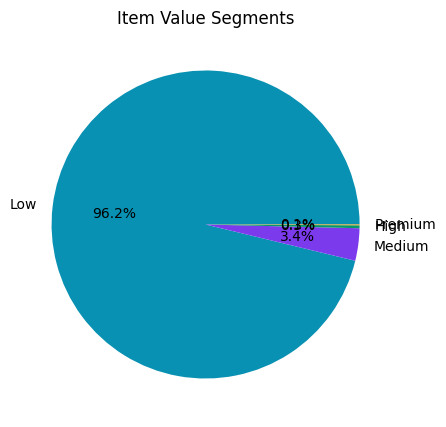


Average Revenue by Segment:
value_segment
High       20656.64
Low          857.46
Medium      7673.62
Premium    40236.27
Name: projected_annual_value, dtype: float64


In [3]:
# Value Segmentation (similar to LTV segments)
def segment_value(value):
    if value < 5000:
        return 'Low'
    elif value < 15000:
        return 'Medium'
    elif value < 30000:
        return 'High'
    else:
        return 'Premium'

item_value['value_segment'] = item_value['projected_annual_value'].apply(segment_value)

print("Value Segment Distribution:")
print(item_value['value_segment'].value_counts())

# Plot segment distribution
plt.figure(figsize=(8,5))
segment_counts = item_value['value_segment'].value_counts()
colors = ['#0891B2', '#7C3AED', '#059669', '#F59E0B']
plt.pie(segment_counts.values, labels=segment_counts.index, 
        autopct='%1.1f%%', colors=colors)
plt.title("Item Value Segments")
plt.show()

# Average revenue by segment
print("\nAverage Revenue by Segment:")
print(item_value.groupby('value_segment')['projected_annual_value'].mean().round(2))

Category Value Summary:
      cat_id  total_items    avg_value  total_value
0      FOODS        14370  1454.828174  20905880.86
1    HOBBIES         5650   785.170508   4436213.37
2  HOUSEHOLD        10470  1020.944355  10689287.40


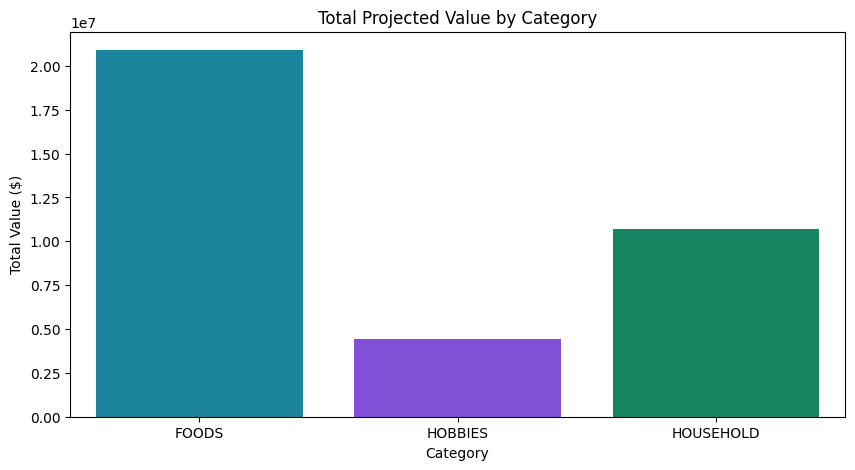


Premium Items by Category:
cat_id
FOODS        21
HOUSEHOLD     3
HOBBIES       1
Name: count, dtype: int64


In [4]:
# Category Value Comparison
cat_value = item_value.groupby('cat_id').agg(
    total_items=('item_id', 'count'),
    avg_value=('projected_annual_value', 'mean'),
    total_value=('projected_annual_value', 'sum')
).reset_index()

print("Category Value Summary:")
print(cat_value)

# Plot category value
plt.figure(figsize=(10,5))
sns.barplot(x='cat_id', y='total_value', data=cat_value,
            palette=['#0891B2', '#7C3AED', '#059669'])
plt.title("Total Projected Value by Category")
plt.xlabel("Category")
plt.ylabel("Total Value ($)")
plt.show()

# Premium items by category
premium_items = item_value[item_value['value_segment'] == 'Premium']
print("\nPremium Items by Category:")
print(premium_items['cat_id'].value_counts())

In [5]:
# Save item value analysis
item_value.to_csv("../data/item_value_analysis.csv", index=False)

print("Item value analysis saved!")

print("\n" + "="*50)
print("WEEK 3 DAY 1 SUMMARY")
print("="*50)
print("Item Value Analysis Complete")
print("\nTop Item: FOODS_3_120 at CA_3")
print("Annual Value: $71,866.19")
print("\nValue Segments:")
print("Premium: $40,236.27 avg")
print("High: $20,656.64 avg")
print("Medium: $7,673.62 avg")
print("Low: $857.46 avg")
print("\nPremium Items by Category:")
print("FOODS: 21 items")
print("HOUSEHOLD: 3 items")
print("HOBBIES: 1 item")
print("="*50)

Item value analysis saved!

WEEK 3 DAY 1 SUMMARY
Item Value Analysis Complete

Top Item: FOODS_3_120 at CA_3
Annual Value: $71,866.19

Value Segments:
Premium: $40,236.27 avg
High: $20,656.64 avg
Medium: $7,673.62 avg
Low: $857.46 avg

Premium Items by Category:
FOODS: 21 items
HOUSEHOLD: 3 items
HOBBIES: 1 item
